# R04 - Planner-Operation Gap

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Quantificar a diferença entre o que o `IntentPlanner` prevê (viável/
inviável) e o que acontece operacionalmente, usando a matriz derivada
`F04_planner_vs_operation` (combina F02+F03, 600 trials, oracle-testa
240 rejeições reconstruíveis de `three_node_1_repeater`). Ver
`docs/false_rejection_root_cause.md` para a causa raiz identificada por
código. Não roda simulação nem o teste de oracle (já executado por
`scripts/build_f04_planner_operation_matrix.py`) - carrega apenas os
resultados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar matriz e métricas do gap

In [2]:
PROCESSED = RESULTS_DIR / "processed" / "F04_planner_vs_operation"
matrix = pd.read_csv(PROCESSED / "matrix.csv")
gap_metrics = json.load(open(PROCESSED / "gap_metrics.json", encoding="utf-8"))
combined = pd.read_csv(PROCESSED / "combined_trials_with_categories.csv")

assert gap_metrics["n_total"] == len(combined) == 600
assert matrix["count"].sum() == 600
print(json.dumps(gap_metrics, indent=2))
matrix

{
  "n_total": 600,
  "operational_success_rate": 0.2833333333333333,
  "false_feasibility_rate": 0.15,
  "false_rejection_rate": 1.0,
  "fidelity_prediction_error": 0.02194409061001724,
  "delivery_deficit": 0.0,
  "throughput_deficit": 0.0
}


,category,count,interpretation
0,FEASIBLE_AND_SATISFIED,170,previsão correta
1,FEASIBLE_BUT_VIOLATED,30,falsa viabilidade operacional
2,INFEASIBLE_AND_REJECTED,160,rejeição prevista (nunca testada contra oracle)
3,INFEASIBLE_BUT_POTENTIALLY_SATISFIABLE,240,falso negativo do planner (oracle confirma sat...
4,EXECUTION_FAILED,0,"reserva rejeitada pelo próprio SeQUeNCe, apesa..."


## Tabela: origem dos 600 trials (F02 + F03)

In [3]:
by_source = combined.groupby(["source_campaign", "scenario"])["category"].value_counts().unstack(fill_value=0)
save_table(by_source.reset_index(), "R04_category_by_source", directory=TABLES_OUT)
by_source

category                                   FEASIBLE_AND_SATISFIED  \
source_campaign  scenario                                           
F02_routing      diamond_heterogeneous                         30   
                 small_mesh                                    60   
F03_purification linear_chain_2_repeaters                       0   
                 three_node_1_repeater                         80   

category                                   FEASIBLE_BUT_VIOLATED  \
source_campaign  scenario                                          
F02_routing      diamond_heterogeneous                        30   
                 small_mesh                                    0   
F03_purification linear_chain_2_repeaters                      0   
                 three_node_1_repeater                         0   

category                                   INFEASIBLE_AND_REJECTED  \
source_campaign  scenario                                            
F02_routing      diamond_heterogeneous                           0   
                 small_mesh                                      0   
F03_purification linear_chain_2_repeaters                      160   
                 three_node_1_repeater                           0   

category                                   INFEASIBLE_BUT_POTENTIALLY_SATISFIABLE  
source_campaign  scenario                                                          
F02_routing      diamond_heterogeneous                                          0  
                 small_mesh                                                     0  
F03_purification linear_chain_2_repeaters                                       0  
                 three_node_1_repeater                                        240

## Figura: matriz planner-vs-operação

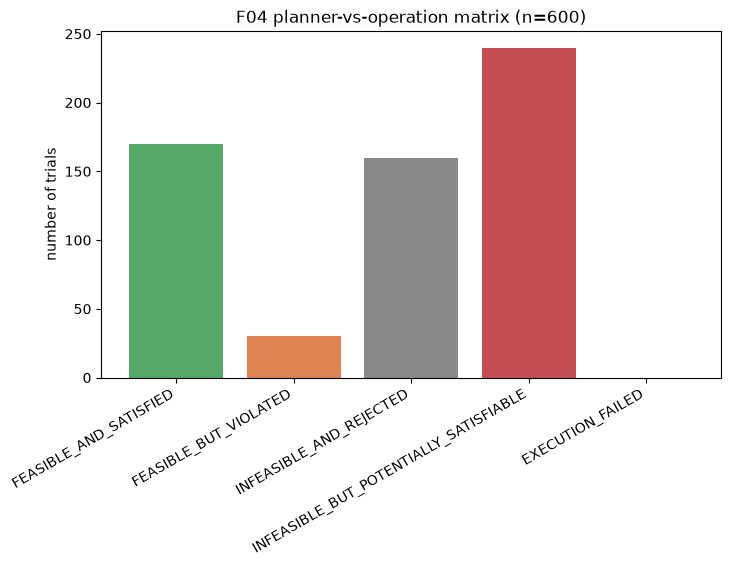

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(matrix["category"], matrix["count"], color=["#55A868", "#DD8452", "#888", "#C44E52", "#7f7f7f"][:len(matrix)])
ax.set_ylabel("number of trials")
ax.set_title(f"F04 planner-vs-operation matrix (n={gap_metrics['n_total']})")
plt.xticks(rotation=30, ha="right")
save_figure(fig, "R04_matrix", directory=FIGURES_OUT)
plt.show()

## Conclusão

`false_rejection_rate=1.0` sobre os 240 trials oracle-testados - o
planner conservador rejeita sistematicamente algo que o SeQUeNCe real
consegue entregar. Causa raiz verificada por código (uma rodada de
purificação estimada vs. múltiplas reais) em
`docs/false_rejection_root_cause.md` - explicitamente não atribuída à
heterogeneidade de topologia (mecanismo diferente, Fase J1).

## Limitações

O oracle só foi rodado sobre `three_node_1_repeater` - `false_rejection_rate=1.0` não deve ser lido como "toda rejeição deste projeto é falsa", só sobre o subconjunto testado (ver `docs/planner_operational_gap.md`).